In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder

 # load data

In [3]:
df = pd.read_csv('shop_smart_ecommerce.csv')
df.head()
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [4]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [5]:
df['Revenue'].value_counts()

Revenue
False    10422
True      1908
Name: count, dtype: int64

In [17]:
df_eda = df.copy()
df_eda['Revenue_Label'] = df_eda['Revenue'].map({True: 'Purchased', False: 'Not Purchased'})
df_eda['Weekend_Label'] = df_eda['Weekend'].map({True: 'Weekend', False: 'Weekday'})
palette = {'Purchased': '#DD8452', 'Not Purchased': '#4C72B0'}
month_order = ['Feb', 'Mar', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
 

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("EDA – ShopSmart Dataset", fontsize=16, fontweight='bold')
revenue_counts = df_eda['Revenue_Label'].value_counts()
bars = axes[0, 0].bar(revenue_counts.index, revenue_counts.values,
                      color=['#4C72B0', '#DD8452'], edgecolor='black')
axes[0, 0].set_title('Target Variable Distribution (Revenue)')
axes[0, 0].set_xlabel('Revenue')
axes[0, 0].set_ylabel('Count')

for bar, val in zip(bars, revenue_counts.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                    str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')


# Monthly purchase rate
axes[0, 0].tick_params(axis='x', rotation=0)
month_df = df_eda.groupby('Month', as_index=False)['Revenue'].mean()
month_df['Month'] = pd.Categorical(month_df['Month'], categories=month_order, ordered=True)
month_df = month_df.dropna(subset=['Month']).sort_values('Month')
sns.barplot(data=month_df, x='Month', y='Revenue', color='#55A868',
            order=month_order, ax=axes[0, 1])
axes[0, 1].set_title('Purchase Rate by Month')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Purchase Rate')
axes[0, 1].tick_params(axis='x', rotation=45)


#Visitor type vs Revenue
visitor_df = df_eda.groupby('VisitorType', as_index=False)['Revenue'].mean() \
                   .sort_values('Revenue', ascending=False)
sns.barplot(data=visitor_df, x='VisitorType', y='Revenue', color='#C44E52', ax=axes[0, 2])
axes[0, 2].set_title('Purchase Rate by Visitor Type')
axes[0, 2].set_xlabel('Visitor Type')
axes[0, 2].set_ylabel('Purchase Rate')
axes[0, 2].tick_params(axis='x', rotation=15)


# PageValues by Revenue
sns.histplot(data=df_eda[df_eda['PageValues'] < 200], x='PageValues',
             hue='Revenue_Label', palette=palette, bins=50,
             alpha=0.7, ax=axes[1, 0])
axes[1, 0].set_title('PageValues Distribution by Revenue')
axes[1, 0].set_xlabel('Page Values')
axes[1, 0].set_ylabel('Frequency')

# BounceRates vs ExitRates 
sns.scatterplot(data=df_eda, x='BounceRates', y='ExitRates',
                hue='Revenue_Label', palette=palette,
                alpha=0.4, s=10, ax=axes[1, 1])
axes[1, 1].set_title('Bounce Rate vs Exit Rate')
axes[1, 1].set_xlabel('Bounce Rate')
axes[1, 1].set_ylabel('Exit Rate')
axes[1, 1].legend(title='Revenue')

# heatmap
num_cols = df_eda.select_dtypes(include=np.number).columns.tolist()
corr = df_eda[num_cols].corr()
sns.heatmap(corr, ax=axes[1, 2], cmap='coolwarm', annot=False,
            linewidths=0.5)
axes[1, 2].set_title('Correlation Heatmap')
axes[1, 2].tick_params(axis='x', rotation=45, labelsize=7)
axes[1, 2].tick_params(axis='y', rotation=0, labelsize=7)

plt.tight_layout()
plt.savefig('img', dpi=150, bbox_inches='tight')

plt.close()

In [20]:
df_processed = df.copy()
 
# Label encode categorical columns 
le = LabelEncoder()
for col in ['Month', 'VisitorType']:
    df_processed[col] = le.fit_transform(df_processed[col])
 
# Convert boolean columns to int  
df_processed[['Weekend', 'Revenue']] = df_processed[['Weekend', 'Revenue']].astype(int)
 
print("\n── Processed Data (first 5 rows) ──")
print(df_processed.head())
 
# Split into features and target
X = df_processed.drop('Revenue', axis=1)
y = df_processed['Revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)
y_pred_base = dt_base.predict(X_test)
f1_base = f1_score(y_test, y_pred_base)
 
print("\n" + "=" * 60)
print("BASELINE DECISION TREE (No Pruning)")
print("=" * 60)
print(f"Tree Depth       : {dt_base.get_depth()}")
print(f"Number of Leaves : {dt_base.get_n_leaves()}")
print(f"F1 Score         : {f1_base:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_base))


── Processed Data (first 5 rows) ──
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay  Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0      2                 1   
1         0.00     

In [22]:
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'ccp_alpha': [0.0, 0.001, 0.005, 0.01, 0.02]
}
 
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train, y_train)
 
print(f"Best Parameters  : {grid_search.best_params_}")
print(f"Best CV F1 Score : {grid_search.best_score_:.4f}")
 
dt_pruned = grid_search.best_estimator_
y_pred_pruned = dt_pruned.predict(X_test)
f1_pruned = f1_score(y_test, y_pred_pruned)
 
print(f"\nPRUNED TREE RESULTS:")
print(f"Tree Depth       : {dt_pruned.get_depth()}")
print(f"Number of Leaves : {dt_pruned.get_n_leaves()}")
print(f"F1 Score         : {f1_pruned:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_pruned))

Best Parameters  : {'ccp_alpha': 0.02, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1 Score : 0.6682

PRUNED TREE RESULTS:
Tree Depth       : 1
Number of Leaves : 2
F1 Score         : 0.6432

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      2084
           1       0.56      0.76      0.64       382

    accuracy                           0.87      2466
   macro avg       0.75      0.83      0.78      2466
weighted avg       0.89      0.87      0.88      2466



In [24]:
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(dt_pruned, feature_names=X.columns.tolist(),
          class_names=['No Purchase', 'Purchase'],
          filled=True, rounded=True, max_depth=4, ax=ax, fontsize=9)
plt.title('Pruned Decision Tree (max display depth=4)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(' img2', dpi=150, bbox_inches='tight')
plt.close()
 

✔ Feature importance plot saved.

ALL DONE! Outputs saved to /mnt/user-data/outputs/


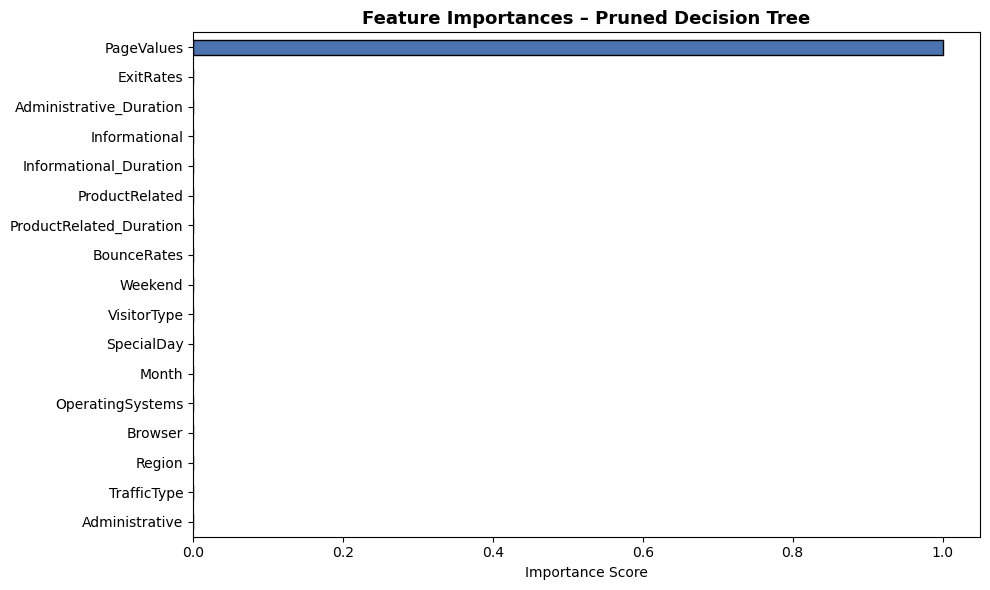

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))
importances = pd.Series(dt_pruned.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).plot(kind='barh', ax=ax,
    color='#4C72B0', edgecolor='black')
ax.set_title('Feature Importances – Pruned Decision Tree', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig(' img3', dpi=150, bbox_inches='tight')
 
print("✔ Feature importance plot saved.")
 
print("\n" + "=" * 60)
print("ALL DONE! Outputs saved to /mnt/user-data/outputs/")
print("=" * 60)
 